<a href="https://colab.research.google.com/github/chaturvedulakashyap-source/Working-Memory-/blob/main/Working_Memory_Attractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

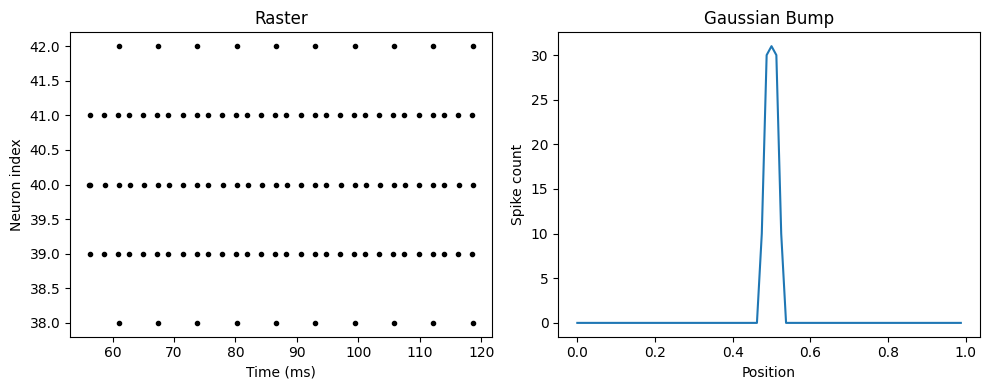

In [25]:
!pip install brian2 matplotlib

from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

N = 80
tau = 10*ms
w_max = 2.0
sigma = 0.01

eqs = '''
dv/dt = (-v + I)/tau : 1
I : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0')
G.v = 'rand()'
G.I = 0

pos = np.arange(N)/N

S = Synapses(G, G, 'w:1', on_pre='v_post += w')
S.connect()

# Gaussian connectivity (circular distance)
for i in range(N):
    for j in range(N):
        d = min(abs(pos[i]-pos[j]), 1-abs(pos[i]-pos[j]))
        S.w[i, j] = w_max * np.exp(-(d**2)/(2*sigma**2)) - 0.4

spike_mon = SpikeMonitor(G)

@network_operation(dt=1*ms)
def stimulus(t):
    if 50*ms < t < 120*ms:
        G.I = '3*exp(-((i-40)**2)/25)'
    else:
        G.I = -0.4

run(400*ms)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.plot(spike_mon.t/ms, spike_mon.i, '.k')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Raster')

plt.subplot(122)
counts = np.bincount(spike_mon.i, minlength=N)
plt.plot(pos, counts)
plt.xlabel('Position')
plt.ylabel('Spike count')
plt.title('Gaussian Bump')

plt.tight_layout()
plt.show()